# Import

In [90]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Plot Accuracy

In [76]:
mode = "image" #  "image" or "text_only"
with open(f"evaluation_results_with_{mode}.json", "r") as f:
    evaluation_data = json.load(f)

In [77]:
# Build DataFrames from the new evaluation_results.json structure
eval_rows = []
group_rows = []

for level_str, stats in evaluation_data.items():
    level = int(level_str)
    eval_rows.append({
        "level": level,
        "correct": stats.get("correct", 0),
        "total": stats.get("total", 0),
        "acc": stats.get("acc", 0.0),
    })

    by_group = stats.get("by_rel_group", {}) or {}
    for g_name, g_stats in by_group.items():
        group_rows.append({
            "level": level,
            "rel_group": g_name,
            "correct": g_stats.get("correct", 0),
            "total": g_stats.get("total", 0),
            "acc": g_stats.get("acc", 0.0),
        })

eval_df = pd.DataFrame(eval_rows).sort_values("level").reset_index(drop=True)
group_df = pd.DataFrame(group_rows).sort_values(["level", "rel_group"]).reset_index(drop=True)

# Labels for plotting
eval_df["level_label"] = eval_df["level"].apply(lambda k: f"level {k}")
if not group_df.empty:
    group_df["level_label"] = group_df["level"].apply(lambda k: f"level {k}")

eval_df.head()

,level,correct,total,acc,level_label
0,0,119,315,37.777778,level 0
1,1,111,307,36.156352,level 1
2,2,211,345,61.159420,level 2
3,3,219,383,57.180157,level 3
4,4,213,389,54.755784,level 4


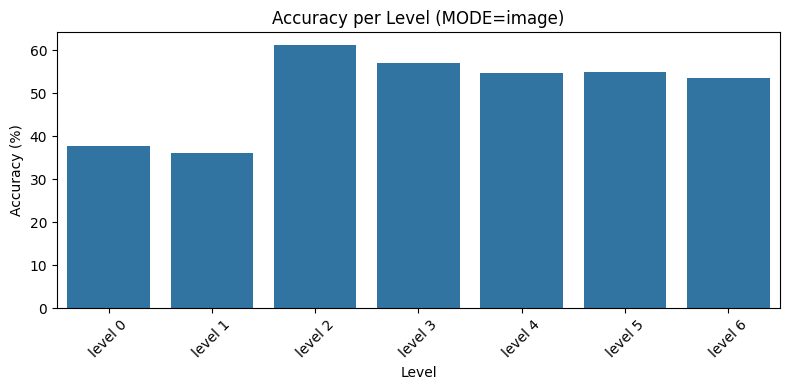

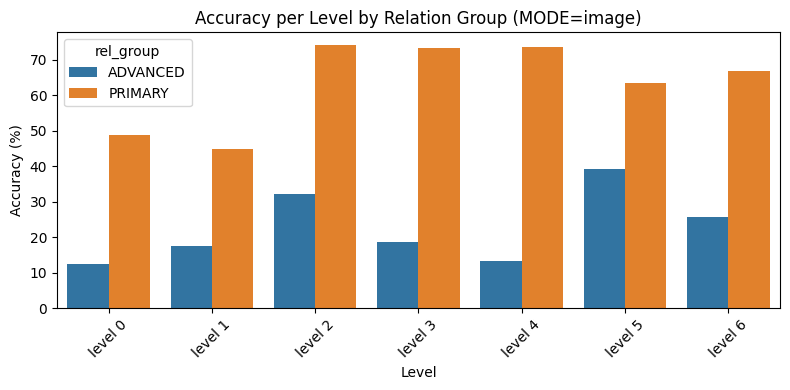

In [78]:
# Plot 1: Overall accuracy per level
plt.figure(figsize=(8, 4))
sns.barplot(data=eval_df, x="level_label", y="acc")
plt.xlabel("Level")
plt.ylabel("Accuracy (%)")
plt.title(f"Accuracy per Level (MODE={mode})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Accuracy per level, split by relation group
if not group_df.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=group_df, x="level_label", y="acc", hue="rel_group")
    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level by Relation Group (MODE={mode})")
    plt.xticks(rotation=45)
    plt.legend(title="rel_group")
    plt.tight_layout()
    # plt.sho()
    plt.savefig(f"accuracy_plot_{mode}.png")
else:
    print("No by_rel_group data found in evaluation_results.json")

In [79]:
# Optional: view per-group table
group_df.head(10)

,level,rel_group,correct,total,acc,level_label
0,0,ADVANCED,12,96,12.500000,level 0
1,0,PRIMARY,107,219,48.858447,level 0
2,1,ADVANCED,17,97,17.525773,level 1
3,1,PRIMARY,94,210,44.761905,level 1
4,2,ADVANCED,34,106,32.075472,level 2
5,2,PRIMARY,177,239,74.058577,level 2
6,3,ADVANCED,21,113,18.584071,level 3
7,3,PRIMARY,198,270,73.333333,level 3
8,4,ADVANCED,16,121,13.223140,level 4
9,4,PRIMARY,197,268,73.507463,level 4


# Reading Logs

In [113]:
mode = "image"
logs_df = pd.read_csv(f"./model_calls_log_with_{mode}.csv")
list(logs_df[(logs_df["Model_Prediction"] == "no") & (logs_df["Ground_Truth"] == "yes")]['Image_Path'])

['/home/kkarthikeyan/deep-learning/DeepLearningProject/Synthetic-Data/vlm_levels/level_5/images/00015_b.png',
 '/home/kkarthikeyan/deep-learning/DeepLearningProject/Synthetic-Data/vlm_levels/level_5/images/00015_b.png',
 '/home/kkarthikeyan/deep-learning/DeepLearningProject/Synthetic-Data/vlm_levels/level_6/images/00006_w.png',
 '/home/kkarthikeyan/deep-learning/DeepLearningProject/Synthetic-Data/vlm_levels/level_6/images/00007_b.png',
 '/home/kkarthikeyan/deep-learning/DeepLearningProject/Synthetic-Data/vlm_levels/level_6/images/00005_b.png']

In [92]:
logs_df["Model_Prediction"].value_counts(dropna=False)

Model_Prediction
yes    2361
no      167
Name: count, dtype: int64

In [93]:
logs_df["Ground_Truth"].value_counts(dropna=False)

Ground_Truth
no     1383
yes    1145
Name: count, dtype: int64

## Plot Confusion Matrix

In [94]:


def generate_confusion_matrix(csv_file, output_image='confusion_matrix.png'):
    # 1. Load the data
    df = pd.read_csv(csv_file)

    # 2. Clean and Normalize labels (handling whitespace/case)
    y_true = df['Ground_Truth'].str.strip().str.lower()
    y_pred = df['Model_Prediction'].str.strip().str.lower()

    # 3. Compute Confusion Matrix
    # We explicitly set labels to ensure the order is consistent
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 4. Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Yes', 'Predicted No'], 
                yticklabels=['Actual Yes', 'Actual No'])

    plt.title('VLM Relational Reasoning Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # 5. Save and Show
    plt.savefig(output_image, bbox_inches='tight', dpi=300)
    print(f"Confusion matrix saved to {output_image}")
    plt.show()

Confusion matrix saved to confusion_matrix.png


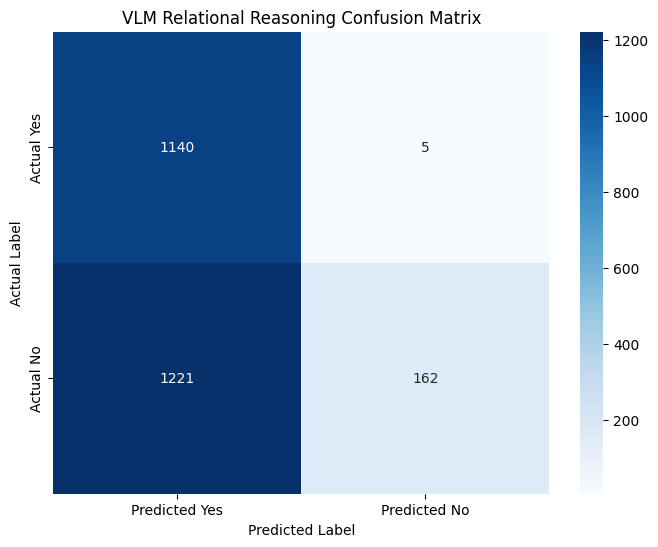

In [97]:
generate_confusion_matrix("./model_calls_log_with_image.csv")

Confusion matrix saved to confusion_matrix.png


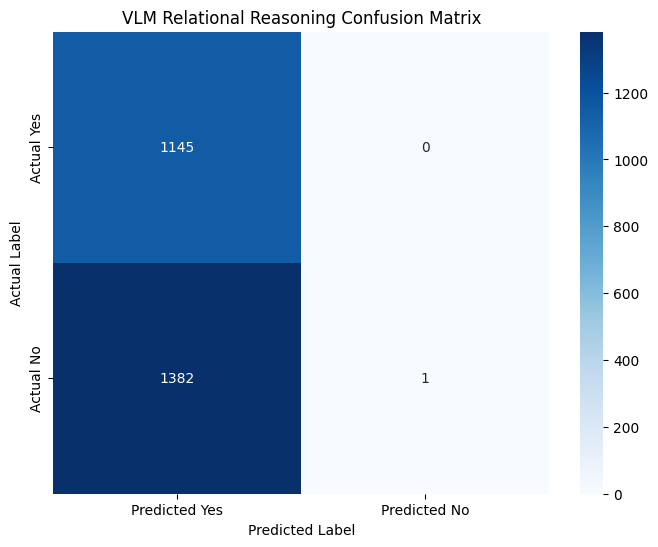

In [98]:
generate_confusion_matrix("./model_calls_log_with_text_only.csv")